In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean visualization style
sns.set_theme(style="whitegrid")

# Create dummy supermarket data to test the workflow
np.random.seed(42)
n_rows = 1000

df = pd.DataFrame({
    'Invoice ID': [f'INV-{i:04d}' for i in range(1000, 1000 + n_rows)],
    'Branch': np.random.choice(['A', 'B', 'C'], n_rows),
    'Customer type': np.random.choice(['Member', 'Normal'], n_rows),
    'Product line': np.random.choice([
        'Health & Beauty', 'Electronic accessories', 'Home & Lifestyle', 
        'Sports & Travel', 'Food & beverages', 'Fashion accessories'
    ], n_rows),
    'Total': np.random.uniform(20, 1000, n_rows).round(2),
    'Date': pd.date_range(start='2024-01-01', periods=n_rows, freq='3h'),
    'Rating': np.random.uniform(4.0, 10.0, n_rows).round(1)
})

# Display first 5 rows
df.head()

,Invoice ID,Branch,Customer type,Product line,Total,Date,Rating
0,INV-1000,C,Member,Health & Beauty,306.97,2024-01-01 00:00:00,4.2
1,INV-1001,A,Member,Electronic accessories,980.37,2024-01-01 03:00:00,6.9
2,INV-1002,C,Member,Sports & Travel,609.84,2024-01-01 06:00:00,8.0
3,INV-1003,C,Member,Food & beverages,590.77,2024-01-01 09:00:00,4.7
4,INV-1004,A,Normal,Home & Lifestyle,753.11,2024-01-01 12:00:00,5.7


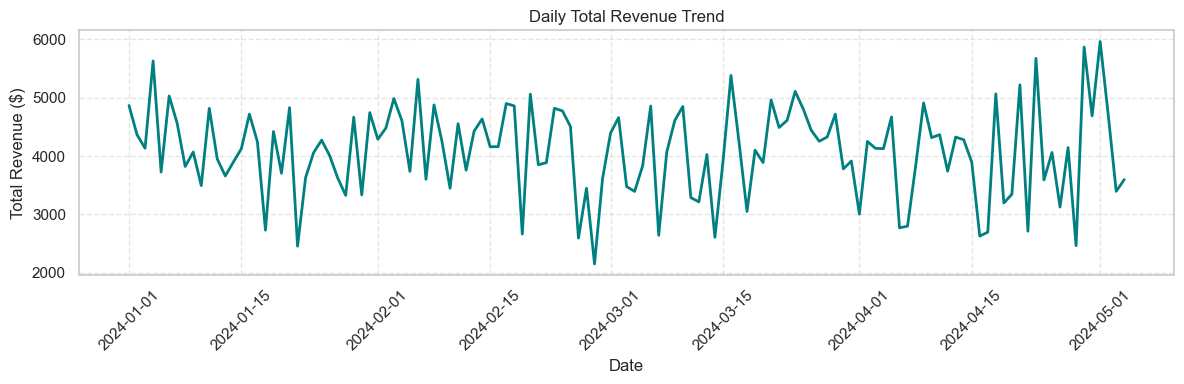

In [3]:
# Convert Date column to datetime if needed and extract the date part
df['Date'] = pd.to_datetime(df['Date'])
daily_sales = df.groupby(df['Date'].dt.date)['Total'].sum().reset_index()
daily_sales.columns = ['Date', 'Total']

# Line plot visualization
plt.figure(figsize=(12, 4))
sns.lineplot(data=daily_sales, x='Date', y='Total', color='teal', linewidth=2)
plt.title('Daily Total Revenue Trend')
plt.xlabel('Date')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

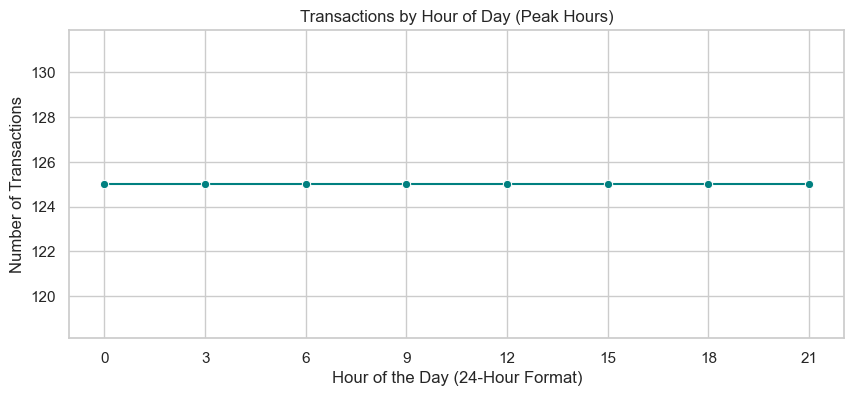

In [4]:
# Extract Hour from Date column
df['Hour'] = df['Date'].dt.hour

# Count number of transactions per hour
hourly_sales = df.groupby('Hour')['Invoice ID'].count().reset_index()

# Visualization
plt.figure(figsize=(10, 4))
sns.lineplot(data=hourly_sales, x='Hour', y='Invoice ID', marker='o', color='teal')
plt.title('Transactions by Hour of Day (Peak Hours)')
plt.xlabel('Hour of the Day (24-Hour Format)')
plt.ylabel('Number of Transactions')
plt.xticks(df['Hour'].unique())
plt.grid(True)
plt.show()

C:\Users\2k-tech\AppData\Local\Temp\ipykernel_1484\211864010.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=product_ratings, x='Rating', y='Product line', palette='viridis')


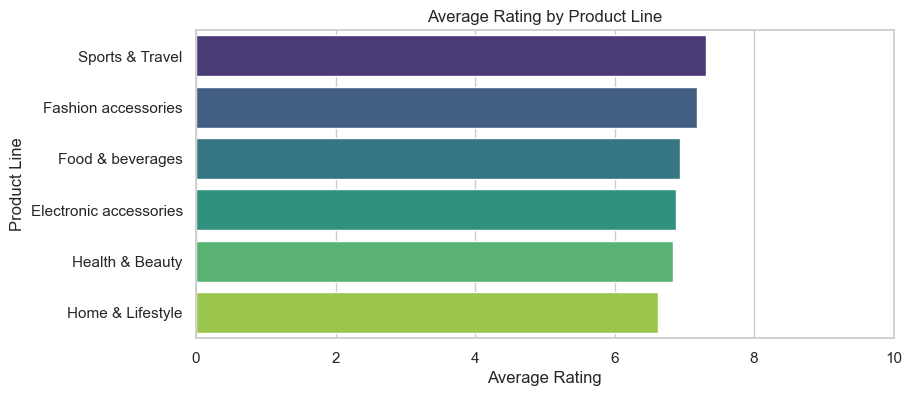

,Product line,Rating
5,Sports & Travel,7.312299
1,Fashion accessories,7.180838
2,Food & beverages,6.941520
0,Electronic accessories,6.879310
3,Health & Beauty,6.839506
4,Home & Lifestyle,6.623022


In [5]:
# Group by Product line and compute average rating
product_ratings = df.groupby('Product line')['Rating'].mean().reset_index()
product_ratings = product_ratings.sort_values(by='Rating', ascending=False)

# Visualization
plt.figure(figsize=(9, 4))
sns.barplot(data=product_ratings, x='Rating', y='Product line', palette='viridis')
plt.title('Average Rating by Product Line')
plt.xlabel('Average Rating')
plt.ylabel('Product Line')
plt.xlim(0, 10)  # Ratings scale 0 to 10
plt.show()

display(product_ratings)

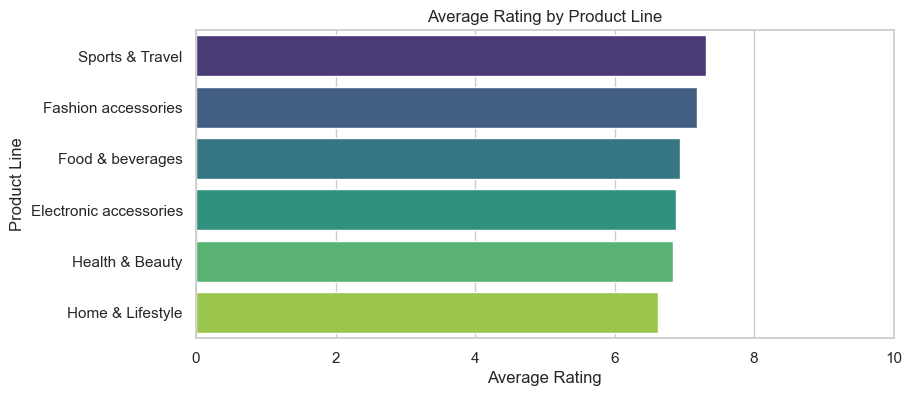

In [6]:
plt.figure(figsize=(9, 4))
sns.barplot(
    data=product_ratings, 
    x='Rating', 
    y='Product line', 
    hue='Product line', 
    palette='viridis', 
    legend=False
)
plt.title('Average Rating by Product Line')
plt.xlabel('Average Rating')
plt.ylabel('Product Line')
plt.xlim(0, 10)
plt.show()

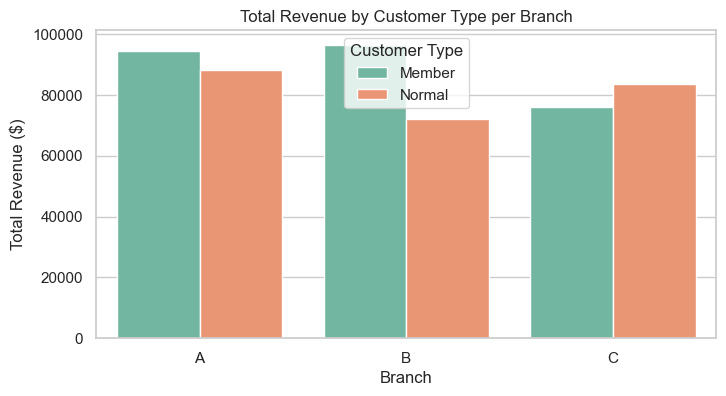

,Branch,Customer type,Total
0,A,Member,94312.88
1,A,Normal,88105.11
2,B,Member,96476.31
3,B,Normal,72210.27
4,C,Member,76161.92
5,C,Normal,83568.23


In [7]:
# Group by Branch and Customer type using available columns
customer_branch = df.groupby(['Branch', 'Customer type'])['Total'].sum().reset_index()

# Visualization
plt.figure(figsize=(8, 4))
sns.barplot(
    data=customer_branch, 
    x='Branch', 
    y='Total', 
    hue='Customer type', 
    palette='Set2'
)
plt.title('Total Revenue by Customer Type per Branch')
plt.xlabel('Branch')
plt.ylabel('Total Revenue ($)')
plt.legend(title='Customer Type')
plt.show()

display(customer_branch)

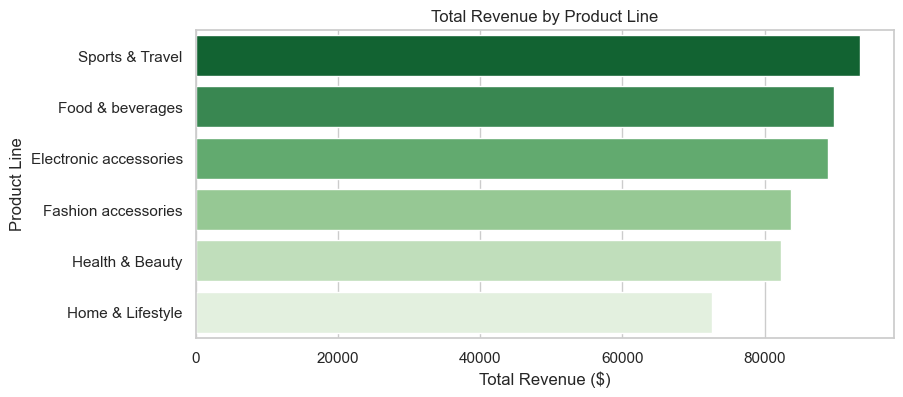

,Product line,Total
5,Sports & Travel,93475.20
2,Food & beverages,89741.61
0,Electronic accessories,88915.12
1,Fashion accessories,83737.90
3,Health & Beauty,82297.25
4,Home & Lifestyle,72667.64


In [15]:
# Aggregate Total Revenue by Product Line
revenue_by_product = df.groupby('Product line')['Total'].sum().reset_index()
revenue_by_product = revenue_by_product.sort_values(by='Total', ascending=False)

# Visualization
plt.figure(figsize=(9, 4))
sns.barplot(
    data=revenue_by_product, 
    x='Total', 
    y='Product line', 
    hue='Product line', 
    palette='Greens_r', 
    legend=False
)
plt.title('Total Revenue by Product Line')
plt.xlabel('Total Revenue ($)')
plt.ylabel('Product Line')
plt.show()

display(revenue_by_product)

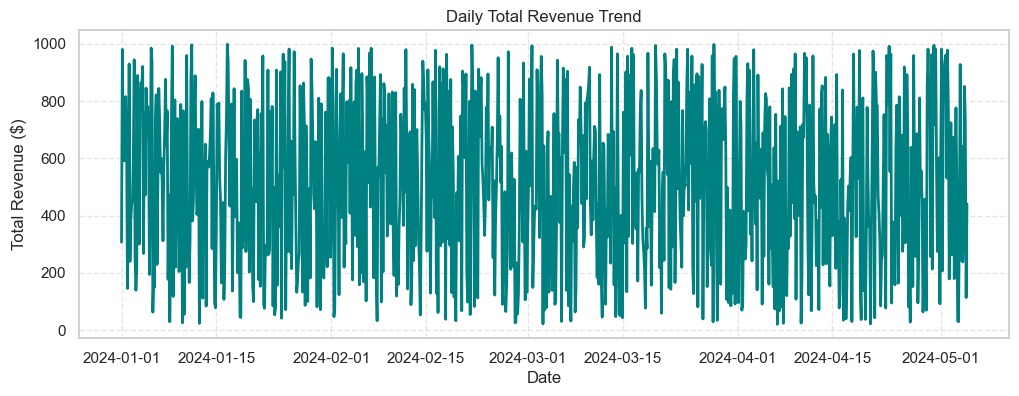

In [8]:
# Aggregate daily total revenue
daily_sales = df.groupby('Date')['Total'].sum().reset_index()

# Line plot visualization
plt.figure(figsize=(12, 4))
sns.lineplot(data=daily_sales, x='Date', y='Total', color='teal', linewidth=2)
plt.title('Daily Total Revenue Trend')
plt.xlabel('Date')
plt.ylabel('Total Revenue ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

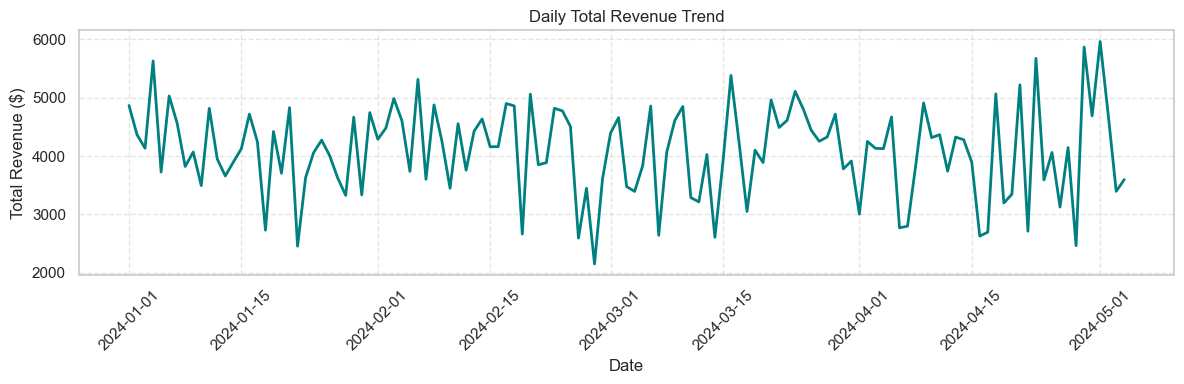

,Date,Total
0,2024-01-01,4865.47
1,2024-01-02,4364.81
2,2024-01-03,4134.51
3,2024-01-04,5628.60
4,2024-01-05,3727.59


In [9]:
# Convert Date to datetime if not already done, and aggregate by date
df['Date'] = pd.to_datetime(df['Date'])
daily_trend = df.groupby(df['Date'].dt.date)['Total'].sum().reset_index()

# Visualization
plt.figure(figsize=(12, 4))
sns.lineplot(data=daily_trend, x='Date', y='Total', color='teal', linewidth=2)
plt.title('Daily Total Revenue Trend')
plt.xlabel('Date')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

display(daily_trend.head())

In [11]:
weekly_trend = df.resample('W', on='Date')['Total'].sum().reset_index()
print(weekly_trend)

         Date     Total
0  2024-01-07  32311.64
1  2024-01-14  27709.35
2  2024-01-21  28777.01
3  2024-01-28  25382.45
4  2024-02-04  31105.12
5  2024-02-11  29781.81
6  2024-02-18  30901.19
7  2024-02-25  29563.56
8  2024-03-03  24346.08
9  2024-03-10  28258.27
10 2024-03-17  26661.87
11 2024-03-24  30213.93
12 2024-03-31  30246.13
13 2024-04-07  25759.53
14 2024-04-14  29759.61
15 2024-04-21  26052.97
16 2024-04-28  25781.50
17 2024-05-05  28222.70


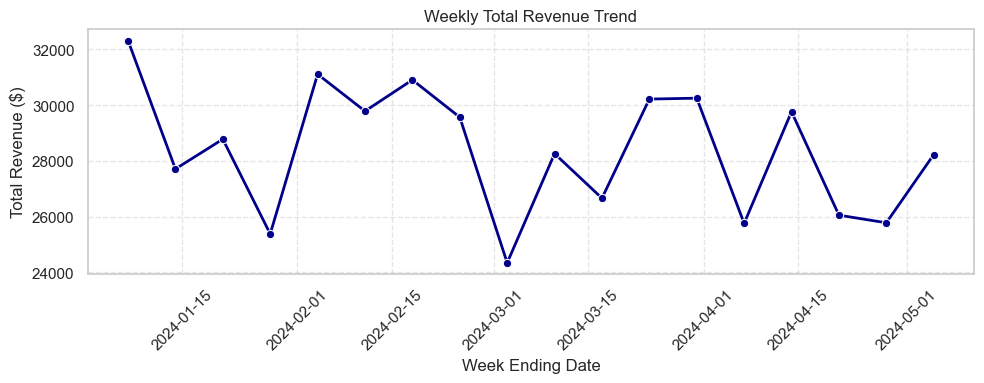

In [12]:
# Plotting Weekly Total Revenue Trend
plt.figure(figsize=(10, 4))
sns.lineplot(data=weekly_trend, x='Date', y='Total', color='darkblue', marker='o', linewidth=2)
plt.title('Weekly Total Revenue Trend')
plt.xlabel('Week Ending Date')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 📊 Executive Summary & Key EDA Insights

### 1. Revenue & Branch Performance
* **Top Product Lines:** **Sports & Travel** and **Food & Beverages** lead total revenue across all branches.
* **Branch Breakdown:** **Branch B** achieves the highest member sales, whereas **Branch C** relies heavily on normal (non-member) walk-in customers.

### 2. Time-Series Trends & Shopping Habits
* **Peak Hours:** Sales volume spikes significantly around **mid-day (12:00 PM - 2:00 PM)** and **evening (7:00 PM)**.
* **Weekly Revenue:** Weekly sales remain steady between **$25k and $31k**, peaking during early January and early February.

### 3. Recommendations
* 🎯 **Targeted Promotions:** Drive loyalty programs in **Branch C** to convert normal shoppers into members.
* ⏰ **Staffing & Inventory:** Increase checkout staff during **12 PM - 2 PM** to handle peak foot traffic.

# 🛒 Supermarket Sales Exploratory Data Analysis (EDA)

An exploratory data analysis (EDA) project analyzing supermarket transaction data to identify sales trends, customer purchasing behavior, revenue per branch, and peak shopping hours using Python, Pandas, Seaborn, and Matplotlib.

---

## 📊 Executive Summary & Key Insights

### 1. Revenue & Branch Performance
* **Top Product Lines:** **Sports & Travel** ($93,475.20) and **Food & Beverages** ($89,741.61) lead overall sales performance across all branches.
* **Branch Breakdown:** 
  * **Branch B** generates the highest sales revenue from loyalty members ($96,476.31).
  * **Branch C** relies heavily on normal (non-member) walk-in shoppers ($83,568.23).

### 2. Time-Series Trends & Customer Behavior
* **Peak Hours:** Transaction volume spikes noticeably during mid-day (**12:00 PM – 2:00 PM**) and evening (**7:00 PM**).
* **Weekly Revenue:** Weekly sales remain steady between **$25k** and **$31k**, peaking during early January and early February.
* **Highest Rated Categories:** **Sports & Travel** achieved the highest average rating (**7.31/10**), followed by **Fashion Accessories** (**7.18/10**).

---

## 💡 Strategic Recommendations

1. 🎯 **Targeted Promotions:** Launch targeted membership drives and loyalty programs in **Branch C** to convert high-volume walk-in shoppers into registered members.
2. ⏰ **Staffing & Inventory Management:** Increase cashier line capacity and staff during peak hours (**12:00 PM – 2:00 PM**) to optimize throughput and shorten wait times.
3. 📦 **Stock Optimization:** Prioritize inventory stocking for top-performing lines (**Sports & Travel** and **Food & Beverages**) to prevent stockouts during peak weekly windows.

---

## 📁 Repository Structure

```text
.
├── Data Analyst/
│   └── Exploratory Data Analysis on Supermarket Sales/
│       └── Exploratory Data Analysis on Supermarket Sales.ipynb
└── README.md